# Forecasting each merchant's next 12 months

The BNPL firm onboards merchants for the future, so the ranking should use what each merchant is **expected to
earn the firm next year**, not just what it did in the past. This notebook forecasts two things for every merchant
for the 12 months after the data ends (27 Oct 2022 to 26 Oct 2023):

1. **Sales**, and from them BNPL revenue (`take_rate` x sales).
2. **Fraud rate**: the share of those sales expected to be fraudulent.

`features.ipynb` found broadly similar seasonal patterns across categories and growth medians across size groups.
This suggests a simple forecast could work as well as a complex one, so several candidate methods are tested
on data they haven't seen before one is chosen.

This notebook only needs the merchant-day totals from `features.ipynb`, so it runs in pandas without Spark.

Output: `curated/merchant_forecast.parquet`, one row per merchant.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
CURATED = Path("curated")              # files the notebooks pass to each other
PLOTS = Path("plots")                  # charts, saved for the presentation
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
MERCHANT_FEATURES = CURATED / "merchant_features.parquet"    # from features.ipynb
MERCHANT_FORECAST = CURATED / "merchant_forecast.parquet"    # from forecast.ipynb

# Key dates
LAST_DAY = "2022-10-26"         # last day of the transactions
SECOND_SNAPSHOT = "2021-08-28"  # first day of the second snapshot: the fraud files flag ~6x more from here
COVERAGE_END = "2022-02-27"     # last day either fraud file covers
LAST_12M_START = "2021-10-27"   # the last 12 months of data: 27 Oct 2021 - 26 Oct 2022

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
apply_style()

daily = pd.read_parquet(MERCHANT_DAILY)
daily["order_datetime"] = pd.to_datetime(daily["order_datetime"])
features = pd.read_parquet(MERCHANT_FEATURES).set_index("merchant_abn")


def window(first, last):
    """Totals per merchant between two dates (inclusive), with a row for every merchant (0 if no sales)."""
    rows = daily[daily["order_datetime"].between(first, last)]
    totals = rows.groupby("merchant_abn")[["transactions", "sales", "revenue", "expected_fraud"]].sum()
    return totals.reindex(features.index, fill_value=0)

def validation_window(frame, first, last):
    rows = frame[frame["order_datetime"].between(first, last)]
    totals = rows.groupby("merchant_abn")[["transactions", "sales", "revenue", "expected_fraud"]].sum()
    return totals.reindex(features.index, fill_value=0)

revenue_validation = pd.read_parquet(CURATED / "revenue_validation_daily.parquet")
revenue_validation["order_datetime"] = pd.to_datetime(revenue_validation["order_datetime"])
fraud_validation = pd.read_parquet(CURATED / "fraud_validation_daily.parquet")
fraud_validation["order_datetime"] = pd.to_datetime(fraud_validation["order_datetime"])


## 1. Testing forecast methods on the last six months

To test a method fairly, pretend it's **27 Apr 2022**. Each method forecasts every merchant's revenue for the next
182 days (28 Apr to 26 Oct 2022) using data available through that date. Merchant-specific outlier thresholds are also fitted only through
27 Apr and then applied to the held-out purchases. Merchants without prior sales retain their valid held-out
purchases and receive a zero-history forecast. Predictions are compared with the resulting held-out revenue.

| Method | Forecast for the next 182 days |
|---|---|
| A. last 6 months | the merchant's revenue in the previous 182 days |
| B. same 6 months last year | the merchant's revenue in 28 Apr - 26 Oct **2021** |
| C. B x market growth | B, grown by the whole market's year-on-year growth |
| D. B x the merchant's own growth | B, grown by the merchant's own year-on-year growth |
| E. share of the last 12 months | the merchant's share of all revenue over the previous 12 months, times the market forecast (C summed over all merchants) |

Growth is measured over 28 Feb to 27 Apr, comparing 2022 with 2021: the only stretch before the cut-off that has
both years.

In [4]:
target = validation_window(revenue_validation, "2022-04-28", LAST_DAY)["revenue"]
last_6m = validation_window(revenue_validation, "2021-10-28", "2022-04-27")["revenue"]
same_6m_last_year = validation_window(revenue_validation, "2021-04-28", "2021-10-26")["revenue"]
last_12m = validation_window(revenue_validation, "2021-04-28", "2022-04-27")["revenue"]  # 365 days
growth_now, growth_then = validation_window(revenue_validation, "2022-02-28", "2022-04-27"), validation_window(revenue_validation, "2021-02-28", "2021-04-27")

market_growth = growth_now["revenue"].sum() / growth_then["revenue"].sum()
own_growth = (growth_now["revenue"] / growth_then["revenue"]).replace([np.inf, -np.inf], np.nan).fillna(market_growth)
market_forecast = (same_6m_last_year * market_growth).sum()

methods = {
    "A. last 6 months": last_6m,
    "B. same 6 months last year": same_6m_last_year,
    "C. B x market growth": same_6m_last_year * market_growth,
    "D. B x merchant's own growth": same_6m_last_year * own_growth,
    "E. share of the last 12 months": last_12m / last_12m.sum() * market_forecast,
}


def score(forecast, actual=target):
    both = (forecast > 0) & (actual > 0)
    log_error = np.log(forecast[both]) - np.log(actual[both])
    return {
        "error, $-weighted (WAPE)": (forecast - actual).abs().sum() / actual.sum(),
        "R² on log revenue": 1 - (log_error ** 2).sum() / ((np.log(actual[both]) - np.log(actual[both]).mean()) ** 2).sum(),
        "rank correlation (Spearman)": spearmanr(forecast, actual).statistic,
        "actual top 100 found": len(set(forecast.nlargest(100).index) & set(actual.nlargest(100).index)),
        "total forecast / actual": forecast.sum() / actual.sum(),
    }


backtest = pd.DataFrame({name: score(forecast) for name, forecast in methods.items()}).T
print(f"market growth used by C and E: {market_growth - 1:+.1%} (28 Feb - 27 Apr, 2022 vs 2021)")
display(backtest.style.format({"error, $-weighted (WAPE)": "{:.1%}", "R² on log revenue": "{:.3f}",
                               "rank correlation (Spearman)": "{:.3f}", "actual top 100 found": "{:.0f}",
                               "total forecast / actual": "{:.2f}"}))
backtest.to_csv(CURATED / "forecast_validation.csv")


# Segment validation supports the decision to use a common business score.
selected = methods["E. share of the last 12 months"]
segment_results = []
for segment in sorted(features["segment"].unique()):
    ids = features.index[features["segment"] == segment]
    prediction, actual = selected.loc[ids], target.loc[ids]
    segment_results.append({
        "segment": segment,
        "revenue_WAPE": float((prediction - actual).abs().sum() / actual.sum()),
        "revenue_rank_correlation": float(spearmanr(prediction, actual).statistic),
        "actual_top10_revenue_found": len(set(prediction.nlargest(10).index) & set(actual.nlargest(10).index)),
    })
segment_validation = pd.DataFrame(segment_results)
segment_validation.to_csv(CURATED / "segment_forecast_validation.csv", index=False)
display(segment_validation.set_index("segment").round(3))


market growth used by C and E: +21.0% (28 Feb - 27 Apr, 2022 vs 2021)


,"error, $-weighted (WAPE)",R² on log revenue,rank correlation (Spearman),actual top 100 found,total forecast / actual
A. last 6 months,9.7%,0.960,0.976,98,0.93
B. same 6 months last year,17.9%,0.947,0.971,99,0.83
C. B x market growth,5.8%,0.957,0.971,99,1.01
D. B x merchant's own growth,13.3%,0.875,0.935,97,1.04
E. share of the last 12 months,4.9%,0.970,0.979,98,1.01


,revenue_WAPE,revenue_rank_correlation,actual_top10_revenue_found
segment,,,
Fashion & Personal Care,0.055,0.975,9
"Hobbies, Arts & Gifts",0.055,0.967,10
Home & Garden,0.053,0.982,10
Outdoor & Auto,0.044,0.987,10
Technology & Media,0.037,0.990,10


Lower WAPE means less total absolute dollar error. The table also checks ranking agreement and whether
the total is over- or under-predicted.

Method E pools each merchant's share over a full year and scales it to the market forecast. It is selected
using this exercise: **model selection on one chronological split**, not a second independent test or a
validated prediction interval. Merchant-specific short-term growth can amplify noise for small merchants.

For the final full-year forecast, method E becomes last-year sales times market growth. Future growth and stable
fraud behaviour remain assumptions.


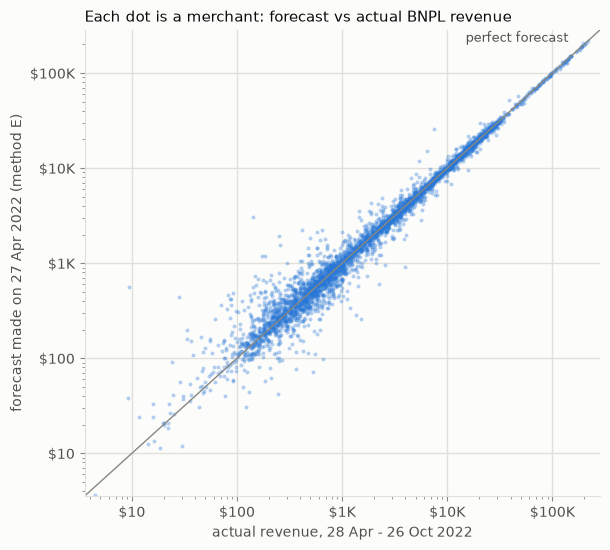

In [5]:
best = methods["E. share of the last 12 months"]
fig, ax = plt.subplots(figsize=(6.2, 5.6))
shown = (best > 0) & (target > 0)
ax.scatter(target[shown], best[shown], s=8, color=BLUE, alpha=0.35, linewidth=0)
limits = [target[shown].min() * 0.8, target.max() * 1.3]
ax.plot(limits, limits, color=MUTED, linewidth=1)
ax.text(limits[1] * 0.5, limits[1] * 0.75, "perfect forecast", color=INK_SECONDARY, fontsize=9, ha="right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.xaxis.set_major_formatter(FuncFormatter(money))
ax.yaxis.set_major_formatter(FuncFormatter(money))
ax.set_xlabel("actual revenue, 28 Apr - 26 Oct 2022")
ax.set_ylabel("forecast made on 27 Apr 2022 (method E)")
ax.set_title("Each dot is a merchant: forecast vs actual BNPL revenue")
fig.tight_layout()
save(fig, "forecast_backtest")
plt.show()

Larger merchants generally have more stable forecasts than those with few orders. Volume/history tiers below
describe the available evidence; they are not statistical confidence intervals.

## 2. Forecasting the fraud rate

Small merchant estimates may be stabilised by blending their rate with their category:

$$\text{rate} = \frac{n}{n+k}\text{own rate} + \frac{k}{n+k}\text{category rate}$$

The blend is selected using **supplied scores only**: rates from 28 Aug-31 Dec 2021 predict Jan-27 Feb 2022.
Outlier thresholds are also fitted only through December. Later model-generated scores are not ground truth.
These are errors against supplied risk estimates, not confirmed losses.


In [6]:
first_half = validation_window(fraud_validation, SECOND_SNAPSHOT, "2021-12-31")
second_half = validation_window(fraud_validation, "2022-01-01", COVERAGE_END)
category = features["category"]


def blended_rate(totals, k):
    own = (totals["expected_fraud"] / totals["sales"]).fillna(0)
    by_category = totals.groupby(category)[["expected_fraud", "sales"]].sum()
    category_rate = category.map(by_category["expected_fraud"] / by_category["sales"])
    weight = (totals["transactions"] / (totals["transactions"] + k)).fillna(0)  # no transactions: category rate
    return weight * own + (1 - weight) * category_rate


actual_rate = second_half["expected_fraud"] / second_half["sales"]
has_both = (first_half["sales"] > 0) & (second_half["sales"] > 0)
k_choices = [0, 5, 10, 20, 50, 100, 200, 500]
k_errors = pd.Series({
    k: np.average((blended_rate(first_half, k) - actual_rate)[has_both].abs(), weights=second_half["sales"][has_both])
    for k in k_choices
}, name="error in fraud rate, weighted by sales")
k_errors.index.name = "k (weight of the category average, in transactions)"
FRAUD_K = int(k_errors.idxmin())
display((100 * k_errors).round(3).to_frame("mean error (percentage points)").T)
print(f"k = {FRAUD_K} minimises error against held-out supplied scores")
k_errors.to_csv(CURATED / "fraud_rate_validation.csv")

"k (weight of the category average, in transactions)",0,5,10,20,50,100,200,500
mean error (percentage points),0.735,0.745,0.768,0.812,0.906,0.992,1.09,1.253


k = 0 minimises error against held-out supplied scores


The selected blend is reported above. The final rate uses all history since 28 Aug 2021, including model
estimates after the supplied scores stop. A merchant with no usable history falls back to its category.
The validation does not establish the accuracy of those later estimates.

## 3. The final forecast

- Sales are last-12-month sales multiplied by the observed market growth factor.
- Limited **observed** history is annualised with at least 90 days assumed; first observed purchase does not prove
  the business itself is new.
- Revenue is forecast sales times take rate; fraud exposure is forecast sales times risk rate.
- The `confidence` labels describe volume/history: low below 100 transactions or one year of observed history,
  medium for 100-999 transactions, high from 1,000. They are not calibrated probabilities.


In [7]:
MIN_HISTORY_DAYS = 90

last_year = window(LAST_12M_START, LAST_DAY)
growth = (window("2022-02-28", LAST_DAY)["sales"].sum() / window("2021-02-28", "2021-10-26")["sales"].sum())
history_days = features["history_days"].clip(upper=365)
annualise = 365 / history_days.clip(lower=MIN_HISTORY_DAYS)

forecast = pd.DataFrame(index=features.index)
forecast["limited_history"] = features["history_days"] < 365
forecast["forecast_sales_12m"] = last_year["sales"] * annualise * growth
forecast["forecast_revenue_12m"] = forecast["forecast_sales_12m"] * features["take_rate"] / 100
forecast["forecast_fraud_rate"] = blended_rate(window(SECOND_SNAPSHOT, LAST_DAY), FRAUD_K)
forecast["fraud_shrinkage_k"] = FRAUD_K
forecast["forecast_fraud_12m"] = forecast["forecast_sales_12m"] * forecast["forecast_fraud_rate"]
forecast["transactions_12m"] = last_year["transactions"]
forecast["confidence"] = np.select(
    [forecast["limited_history"] | (forecast["transactions_12m"] < 100), forecast["transactions_12m"] < 1000],
    ["low", "medium"], default="high")

assert forecast.notna().all().all(), "every merchant has a forecast"
forecast.reset_index().to_parquet(MERCHANT_FORECAST, index=False)
print(f"market growth: {growth - 1:+.1%}; forecast saved for {len(forecast):,} merchants to {MERCHANT_FORECAST}")

summary = forecast.groupby("confidence").agg(merchants=("forecast_sales_12m", "size"),
                                             forecast_revenue=("forecast_revenue_12m", "sum"))
summary["share_of_forecast_revenue"] = summary["forecast_revenue"] / summary["forecast_revenue"].sum()
display(summary.loc[["high", "medium", "low"]].style.format({"forecast_revenue": money, "share_of_forecast_revenue": "{:.1%}"}))

new = features.loc[forecast["limited_history"], ["merchant_name", "category", "first_transaction", "transactions"]]
new = new.join(forecast[["forecast_revenue_12m", "forecast_fraud_rate"]]).sort_values("forecast_revenue_12m", ascending=False)
print(f"{len(new)} merchants have less than a year of history:")
display(new.head(10).style.format({"forecast_revenue_12m": money, "forecast_fraud_rate": "{:.2%}",
                                   "first_transaction": "{:%d %b %Y}"}))

market growth: +20.2%; forecast saved for 4,026 merchants to curated/merchant_forecast.parquet


,merchants,forecast_revenue,share_of_forecast_revenue
confidence,,,
high,1144,$54.9M,74.8%
medium,1545,$14.9M,20.4%
low,1337,$3.6M,4.8%


22 merchants have less than a year of history:


,merchant_name,category,first_transaction,transactions,forecast_revenue_12m,forecast_fraud_rate
merchant_abn,,,,,,
14004773634,Dapibus Gravida Limited,"antique shops - sales, repairs, and restoration services",23 Nov 2021,5,$4K,34.13%
28311306642,Egestas Nunc Sed LLC,"antique shops - sales, repairs, and restoration services",08 Mar 2022,2,$4K,57.37%
89109402284,Interdum Feugiat Sed Incorporated,"antique shops - sales, repairs, and restoration services",16 Nov 2021,3,$4K,69.75%
10165489824,Nunc Sed Company,"jewelry, watch, clock, and silverware shops",30 Nov 2021,5,$3K,40.53%
76866488151,Euismod Urna Company,"antique shops - sales, repairs, and restoration services",10 Mar 2022,4,$3K,38.60%
64094501963,Dictum Mi Corporation,"antique shops - sales, repairs, and restoration services",06 Feb 2022,2,$3K,65.50%
42461534060,Elit LLP,"antique shops - sales, repairs, and restoration services",26 Nov 2021,2,$3K,57.37%
94009500943,Dapibus Corp.,"antique shops - sales, repairs, and restoration services",26 Nov 2021,6,$2K,37.98%
18261886835,Massa Rutrum LLP,"antique shops - sales, repairs, and restoration services",23 Jan 2022,2,$2K,36.55%


In [8]:
low_share = summary.loc["low", "share_of_forecast_revenue"]
show_markdown(f"""
### Summary

- **Method.** Five forecast methods were tested by forecasting 28 Apr to 26 Oct 2022 from the data before it. The best
  (error {backtest.loc['E. share of the last 12 months', 'error, $-weighted (WAPE)']:.1%}, rank correlation
  {backtest.loc['E. share of the last 12 months', 'rank correlation (Spearman)']:.3f}, finding
  {backtest.loc['E. share of the last 12 months', 'actual top 100 found']:.0f} of the actual top 100) is the simplest:
  a merchant's last 12 months, grown at the market rate (**{growth - 1:+.1%}**). Applying a merchant's own growth
  rate made forecasts worse.
- **Fraud rate.** Own and category risk estimates are blended with k = {FRAUD_K}, selected by forecasting Jan-Feb
  supplied scores from Aug-Dec supplied scores. The final rate also includes later model estimates.
- **Uncertainty.** Merchants with low confidence (fewer than 100 transactions in the last year, or less than a year
  of history) are **{summary.loc['low', 'merchants']:,}** of {len(forecast):,}, but only **{low_share:.1%}** of
  forecast revenue. **{len(new)}** merchants have traded for less than a year.

**Output:** `{MERCHANT_FORECAST}`, used by `ranking.ipynb`.
""")


### Summary

- **Method.** Five forecast methods were tested by forecasting 28 Apr to 26 Oct 2022 from the data before it. The best
  (error 4.9%, rank correlation
  0.979, finding
  98 of the actual top 100) is the simplest:
  a merchant's last 12 months, grown at the market rate (**+20.2%**). Applying a merchant's own growth
  rate made forecasts worse.
- **Fraud rate.** Own and category risk estimates are blended with k = 0, selected by forecasting Jan-Feb
  supplied scores from Aug-Dec supplied scores. The final rate also includes later model estimates.
- **Uncertainty.** Merchants with low confidence (fewer than 100 transactions in the last year, or less than a year
  of history) are **1,337** of 4,026, but only **4.8%** of
  forecast revenue. **22** merchants have traded for less than a year.

**Output:** `curated/merchant_forecast.parquet`, used by `ranking.ipynb`.
